In [16]:
import jax.numpy as jnp
import numpy as np
import astropy.units as u
from scipy.optimize import curve_fit
from chromatic import *

visits = {
    'F21': {
        'Grism': 'G141',
        'BJD_times': np.array(pd.read_csv('F21_bjdtimes.csv')['BJD'][:]) * u.day,
        'time_lower': 2459455.708 * u.day,
        'time_upper': 2459455.738 * u.day,
        'T0 (BJD_TDB)': 2459455.9895 * u.day,
        'exp (s)': 4.9784 * u.s,
        'native resolution': 46.3 * u.angstrom
    },
    'S22': {
        'Grism': 'G102',
        'BJD_times': np.array(pd.read_csv('S22_bjdtimes.csv')['BJD'][:]) * u.day,
        'time_lower': 2459684.215 * u.day,
        'time_upper': 2459684.243 * u.day,
        'T0 (BJD_TDB)': 2459684.4959 * u.day, # This is 27 planetary orbits after the first transit, + 0.0054 days (the transit arrived 7 minutes late)
        'exp (s)': 9.67632 * u.s,
        'native resolution': 24.6 * u.angstrom
    }
}

def ramp_model_jax(phase, r1, r2, r3):

    phase = jnp.array(phase)
    _ramp = 1. - jnp.exp( (-r1 * phase) + r2) + (r3 * phase)
    ramp = _ramp/jnp.mean(_ramp)
    
    return jnp.array(ramp)

In [17]:
def bin_testing(visit='F21',bin_edges = None,
                print_results=False,plot=True,verbose=False):
    
    if visit == 'F21':
        time_offset = 2549455 * u.day
        grism = 'G141'
    if visit == 'S22':
        time_offset = 2549684 * u.day
        grism = 'G102'
    'Linear and Residual functions for minimization'
    def linear_model(x, m, b):
        ramp = ramp_model_jax(phase=ramp_phase,r1=17.0,r2=-6.5,r3=0.0)
        return (m * x + b)*ramp
    def residual(params, x, y):
        m, b = params
        model = linear_model(x, m, b)
        return y - model

    if visit == 'F21':
        whitelight_ref_value = -0.00245
    if visit == 'S22':
        whitelight_ref_value = -0.00249
    predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
    
    rainbow = read_rainbow(f"{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
    unbinned_rainbow = rainbow
    if verbose:
        print(f'N_wavelengths in visit {visit} = {rainbow.nwave}')
        print(f'N_times in visit {visit} = {rainbow.ntime}')
    data_wavelengths = rainbow.wavelength.value
    img_date = rainbow.time.value
    _data_flux = rainbow.flux.value
    time_from_T0 = img_date - predicted_T0
    mean_data_flux = np.nanmean(_data_flux, axis=1)
    data_flux = _data_flux / mean_data_flux[:, np.newaxis]
    relative_err = rainbow.uncertainty.value/_data_flux
    'Label the orbits'
    orbit = np.zeros_like(img_date)
    for j in range(len(img_date)):
        if j >= 1:
            if (img_date[j] - img_date[j - 1]) > 0.01:
                orbit[j] = (orbit[j - 1] + 1)
            else:
                orbit[j] = orbit[j - 1]
    'Trim the first point from each orbit'
    ref_time = []
    for o in np.unique(orbit):
        first_index = np.where(orbit == o)[0][0]
        ref_time.append(img_date[first_index])
        data_flux[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
        relative_err[:, first_index] = np.nan
        img_date[first_index] = np.nan
        time_from_T0[first_index] = np.nan
    'Set data to nan if it was in the pre-defined list of orbits to exclude'
    for orbit_to_exclude in np.array([0,3,4,5]):
        data_flux[:, orbit == orbit_to_exclude] = np.nan
        relative_err[:, orbit == orbit_to_exclude] = np.nan
        img_date[orbit == orbit_to_exclude] = np.nan
        time_from_T0[orbit == orbit_to_exclude] = np.nan
    'Populate ramp_phase time arrays'
    phase_list=[]
    for o in [0,1,2,3,4,5,6,7]:
        rphase = (img_date[orbit==o] - ref_time[o]) / 0.066
        phase_list.append(rphase)
    ramp_phase = np.concatenate(phase_list)
    'Calculate the offset between orbits'
    if verbose:
        print('Baseline Offsets at Native Res:')
    baseline_differences = []
    for this_wave in range(data_flux.shape[0]):
        orb1 = data_flux[this_wave, orbit == 1]
        orb2 = data_flux[this_wave, orbit == 2]
        if visit =='S22':
            orb1 = data_flux[this_wave, orbit == 6]
            orb2 = data_flux[this_wave, orbit == 7]
        median_1 = np.nanmedian(orb1)
        median_2 = np.nanmedian(orb2)
        normalized_difference = (median_2-median_1)/whitelight_ref_value
        baseline_differences.append(normalized_difference)
        if verbose:
            print(f'{(normalized_difference):.5f}')
    nanmask = ~np.isnan(img_date)
    data_flux = data_flux[:,nanmask]
    relative_err = relative_err[:,nanmask]
    time_from_T0 = time_from_T0[nanmask]  
    img_date = img_date[nanmask]          
    ramp_phase = ramp_phase[nanmask]
        
    'PLOT EACH LIGHT CURVE WITH THE MODEL, NEXT TO THE RESIDUALS'
    popt_list = []
    initial_guess = [-0.03, 1.0]  # m, b
    for i in range(len(data_wavelengths)):
        flux = data_flux[i, :]
        err = relative_err[i, :]

        popt, pcov = curve_fit(
            lambda x, m, b: linear_model(x, m, b),
            time_from_T0,
            flux,
            sigma = err,
            p0=initial_guess,
            maxfev = 100000
            )
        'Best-fit parameters'
        popt_list.append(popt)
        m_opt, b_opt = popt
        if verbose:
            print("Best-fit params:", popt)
        model_flux = linear_model(time_from_T0, m_opt, b_opt)
        residual = data_flux[i,:]-model_flux
        rms = int(np.nanstd(residual)*1e6)
        chisq = np.nansum((residual/relative_err[i,:])**2)
        rchisq = chisq/(np.sum(~np.isnan(time_from_T0))-2)
        if print_results:
            if i == 0:
                print('Wavelength Median_rel_err linear_rms r_chisq')
            print(f'{data_wavelengths[i]:.5f} {int(np.nanmedian(relative_err[i,:])*1e6)} {rms} {rchisq:.3f}')

    'Calculate Linear Fit and associated RMS '
    rms_list = []
    for i in range(len(data_wavelengths)):
        m_opt, b_opt = popt_list[i]
        model_flux = linear_model(time_from_T0, m_opt, b_opt)
        residual = data_flux[i,:]-model_flux
        rms = int(np.nanstd(residual)*1e6)
        rms_list.append(rms )
        chisq = np.nansum((residual/relative_err[i,:])**2)
        rchisq = chisq/(np.sum(~np.isnan(time_from_T0))-2)
    
    'RMS and Bin Edge Plots'
    if plot:
        fig = plt.figure(figsize=(10, 11))
        
        gs = plt.GridSpec(4, 1, height_ratios=[1, 1, 2, 2], hspace=0.11)
        
        ax0 = fig.add_subplot(gs[0])
        ax1 = fig.add_subplot(gs[1], sharex=ax0)
        ax2 = fig.add_subplot(gs[2], sharex=ax0)
        ax3 = fig.add_subplot(gs[3])
        
        axes = [ax0, ax1, ax2, ax3]
        
        # ax0.set_title(f'{visit} N_bins = {len(bin_edges)-1}')
        ax0.set_title(f'{visit}/{grism}',fontsize=16)
        ax0.set_ylabel(f'Residual RMS (ppm)')
        ax0.plot(data_wavelengths, rms_list, zorder=-100,
                 color='gray',lw=1)
        
        ax1.set_ylabel('Normalized Flux Offset')
        ax1.plot(data_wavelengths, baseline_differences, zorder=-100,
                 color='gray',lw=1)
        ax1.axhline(1.0,color='k')
        
        ax2.set_ylabel(r'Flux [x10$^7$ e$^-$/s]')
        ax2.set_xlabel(r'Wavelength $\mu$m',fontsize=8)
        for t in range(unbinned_rainbow.ntime):
            ax2.plot(unbinned_rainbow.wavelength, unbinned_rainbow.flux[:,t]/1e7,
                          color='k',alpha=0.1,lw=0.5)
        
        ax3.set_ylabel('Relative Flux + Offset')
        ax3.set_xlabel(f'Time from Mid-Transit (d)')

        # Remove x-axis labels from top 3 plots
        plt.setp(ax0.get_xticklabels(), visible=False)
        plt.setp(ax1.get_xticklabels(), visible=False)
        
        for i in range(len(data_wavelengths)):
            ax0.scatter(data_wavelengths[i], rms_list[i],
                        color='pink', zorder=0,alpha=0.6)
            ax1.scatter(data_wavelengths[i], baseline_differences[i],
                        color='pink',zorder=0,alpha=0.6)
        
        for edge in bin_edges.value:
            for ax in axes[:3]:  # Add vertical lines to first 4 plots only
                ax.axvline(edge,color='gray', linewidth=1,zorder=-10000)

            y_max = ax0.get_ylim()[1]
            y_pos = y_max * 0.95  # 95% of the way to the top
            
            # Rotate the label slightly for better readability if many bins
            rotation = 45 if len(bin_edges) > 10 else 0
            
            ax0.text(edge, y_pos, f'{edge:.3f}', 
                    color='k', fontsize=8,
                    horizontalalignment='center',
                    verticalalignment='top',
                    rotation=rotation)

    ###################################################################################################
    'Now do this again but with a binnned light curve'
    rainbow = read_rainbow(f"{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
    rainbow = rainbow.bin(wavelength_edges=bin_edges,minimum_points_per_bin=1)
    data_wavelengths = rainbow.wavelength.value
    img_date = rainbow.time.value
    _data_flux = rainbow.flux.value
    relative_err = rainbow.uncertainty.value/_data_flux
    time_from_T0 = img_date - predicted_T0
    mean_data_flux = np.nanmean(_data_flux, axis=1)
    data_flux = _data_flux / mean_data_flux[:, np.newaxis]

    if plot:
        'Plot the binned light curves'
        for i in range(len(data_wavelengths)):
            flux_i = data_flux[i, :]
            unc_i = relative_err[i, :]
            
            if visit =='F21':
                ax3.errorbar(time_from_T0, flux_i - (0.002 * i), yerr=unc_i, fmt='o', ms=3, alpha=0.8,
                            markeredgecolor='k', markeredgewidth=0.25,
                            color=plt.cm.magma_r((data_wavelengths[i] - data_wavelengths[0]) / 
                                                np.ptp(data_wavelengths)))
            if visit =='S22':
                ax3.errorbar(time_from_T0, flux_i - (0.00305 * i), yerr=unc_i, fmt='o', ms=3, alpha=0.8,
                            markeredgecolor='k', markeredgewidth=0.25,
                            color=plt.cm.cividis((data_wavelengths[i] - data_wavelengths[0]) / 
                                                np.ptp(data_wavelengths)))
        
        x_pos = np.nanmean(time_from_T0) - 0.215
        for i in range(len(data_wavelengths)):
            y_pos = np.nanmax(data_flux[0,:]) - 0.0032 * i
            ax3.annotate(f'{data_wavelengths[i]:.3f} µm', [x_pos, y_pos], fontsize=7.0)
    
    'Label the orbits'
    orbit = np.zeros_like(img_date)
    for j in range(len(img_date)):
        if j >= 1:
            if (img_date[j] - img_date[j - 1]) > 0.01:
                orbit[j] = (orbit[j - 1] + 1)
            else:
                orbit[j] = orbit[j - 1]
    
    'Trim the first point from each orbit'
    ref_time = []
    for o in np.unique(orbit):
        first_index = np.where(orbit == o)[0][0]
        ref_time.append(img_date[first_index])
        data_flux[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
        relative_err[:, first_index] = np.nan
        img_date[first_index] = np.nan
        time_from_T0[first_index] = np.nan
    
    'Set data to nan if it was in the pre-defined list of orbits to exclude'
    for orbit_to_exclude in np.array([0,3,4,5]):
        data_flux[:, orbit == orbit_to_exclude] = np.nan
        relative_err[:, orbit == orbit_to_exclude] = np.nan
        img_date[orbit == orbit_to_exclude] = np.nan
        time_from_T0[orbit == orbit_to_exclude] = np.nan
    
    'Populate ramp_phase time arrays'
    phase_list=[]
    for o in [0,1,2,3,4,5,6,7]:
        rphase = (img_date[orbit==o] - ref_time[o]) / 0.066
        phase_list.append(rphase)
    ramp_phase = np.concatenate(phase_list)

    'Calculate the offset between orbits'
    if verbose:
        print('Baseline Offsets at Binned Res:')
    baseline_differences = []
    for this_wave in range(data_flux.shape[0]):
        orb1 = data_flux[this_wave, orbit == 1]
        orb2 = data_flux[this_wave, orbit == 2]
        if visit =='S22':
            orb1 = data_flux[this_wave, orbit == 6]
            orb2 = data_flux[this_wave, orbit == 7]
        median_1 = np.nanmedian(orb1)
        median_2 = np.nanmedian(orb2)
        normalized_difference = (median_2-median_1)/whitelight_ref_value
        baseline_differences.append(normalized_difference)
        if verbose:
            print(f'{(normalized_difference):.5f}')
    
    nanmask = ~np.isnan(img_date)
    data_flux = data_flux[:,nanmask]
    relative_err = relative_err[:,nanmask]
    time_from_T0 = time_from_T0[nanmask]  
    img_date = img_date[nanmask]          
    ramp_phase = ramp_phase[nanmask]
        
    'Minimize the function to find the best line'
    popt_list = []
    for i in range(len(data_wavelengths)):
        flux = data_flux[i, :]
        err = relative_err[i, :]
        popt, pcov = curve_fit(
            lambda x, m, b: linear_model(x, m, b),
            time_from_T0,
            flux,
            sigma = err,
            p0=initial_guess,
            maxfev = 100000
            )
        'Best-fit parameters'
        popt_list.append(popt)
        m_opt, b_opt = popt
        model_flux = linear_model(time_from_T0, m_opt, b_opt)
        residual = data_flux[i,:]-model_flux
        rms = int(np.nanstd(residual)*1e6)
        chisq = np.nansum((residual/relative_err[i,:])**2)
        rchisq = chisq/(np.sum(~np.isnan(time_from_T0))-2)
        if print_results:
            if i == 0:
                print('BINNED: Wavelength Median_rel_err linear_rms r_chisq')
            print(f'{data_wavelengths[i]:.5f} {int(np.nanmedian(relative_err[i,:])*1e6)} {rms} {rchisq:.3f}')
    
    'Calculate Linear Fit and associated RMS '
    rms_list = []
    for i in range(len(data_wavelengths)):
        m_opt, b_opt = popt_list[i]
        model_flux = linear_model(time_from_T0, m_opt, b_opt)
        residual = data_flux[i,:]-model_flux
        rms = int(np.nanstd(residual)*1e6)
        rms_list.append( rms )
        chisq = np.nansum((residual/relative_err[i,:])**2)
        rchisq = chisq/(np.sum(~np.isnan(time_from_T0))-2)
    
    if plot:
        'Update the first 4 plots with binned data'
        ax0.plot(data_wavelengths, rms_list, color='k',lw=1,zorder=100)
        ax1.plot(data_wavelengths, baseline_differences, color='k',lw=1,zorder=100)
        
        for i in range(len(data_wavelengths)):
            ax0.scatter(data_wavelengths[i], rms_list[i],
                        color='blue', zorder=1000,alpha=0.9,s=16)
            ax1.scatter(data_wavelengths[i], baseline_differences[i],
                        color='blue',zorder=1000,alpha=0.9,s=16)
        
        # ax2.set_ylim(250,1000)
        # ax2.set_yscale('log')
        # ax3.set_ylim(0.8, 1.2)
        ax0.set_yscale('log')

        'Remove internal spacing between subplots'
        plt.subplots_adjust(hspace=0.0)
        fig.tight_layout()
        
        plt.savefig(f'{visit}_{len(bin_edges)-1}bins_bin_plots_withLCs-paperversion.png', dpi=400, bbox_inches='tight')
        plt.show()

    return rms_list, baseline_differences

## Figure 3

1.14064 micron
1.177 micron
1.1941 micron
1.2112 micron
1.229 micron
1.246 micron
1.2649 micron
1.32596 micron
1.34884667 micron
1.39082 micron
1.42325 micron
1.43715 micron
1.48348 micron
1.53444 micron
1.55297 micron
1.5685 micron
1.5925 micron
1.6165 micron
1.6405 micron
Wavelength Median_rel_err linear_rms r_chisq
1.13369 356 5968 287.595
1.13832 357 5162 214.170
1.14296 353 1625 21.630
1.14759 349 452 1.726
1.15222 346 1358 15.776
1.15685 346 1953 32.569
1.16149 346 3207 87.690
1.16612 342 850 6.297
1.17075 339 1692 25.556
1.17539 336 1520 20.974
1.18002 334 1364 16.995
1.18465 332 505 2.368
1.18929 330 672 4.221
1.19392 329 2634 65.766
1.19855 328 1079 11.031
1.20318 326 470 2.135
1.20782 323 422 1.749
1.21245 321 497 2.460
1.21708 320 2320 53.901
1.22172 318 2017 41.043
1.22635 316 529 2.867
1.23098 315 1221 15.365
1.23561 314 1437 21.326
1.24025 313 747 5.789
1.24488 313 1419 20.977
1.24951 313 963 9.672
1.25415 312 319 1.071
1.25878 311 427 1.925
1.26341 311 750 5.948
1.26804 

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

BINNED: Wavelength Median_rel_err linear_rms r_chisq
1.15882 123 270 4.939
1.18555 172 289 2.876
1.20265 169 343 4.205
1.22010 162 301 3.524
1.23750 164 275 2.881
1.25545 154 294 3.724
1.29543 84 252 9.196
1.33740 134 285 4.587
1.36983 100 275 7.657
1.40704 114 286 6.392
1.43020 174 301 3.058
1.46032 96 291 9.447
1.50896 91 301 11.093
1.54371 151 307 4.207
1.56073 166 325 3.928
1.58050 134 347 6.819
1.60450 134 335 6.346
1.62850 136 359 7.064


/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_9229/3559754265.py:334: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.0)
/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_9229/3559754265.py:335: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_9229/3559754265.py:335: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


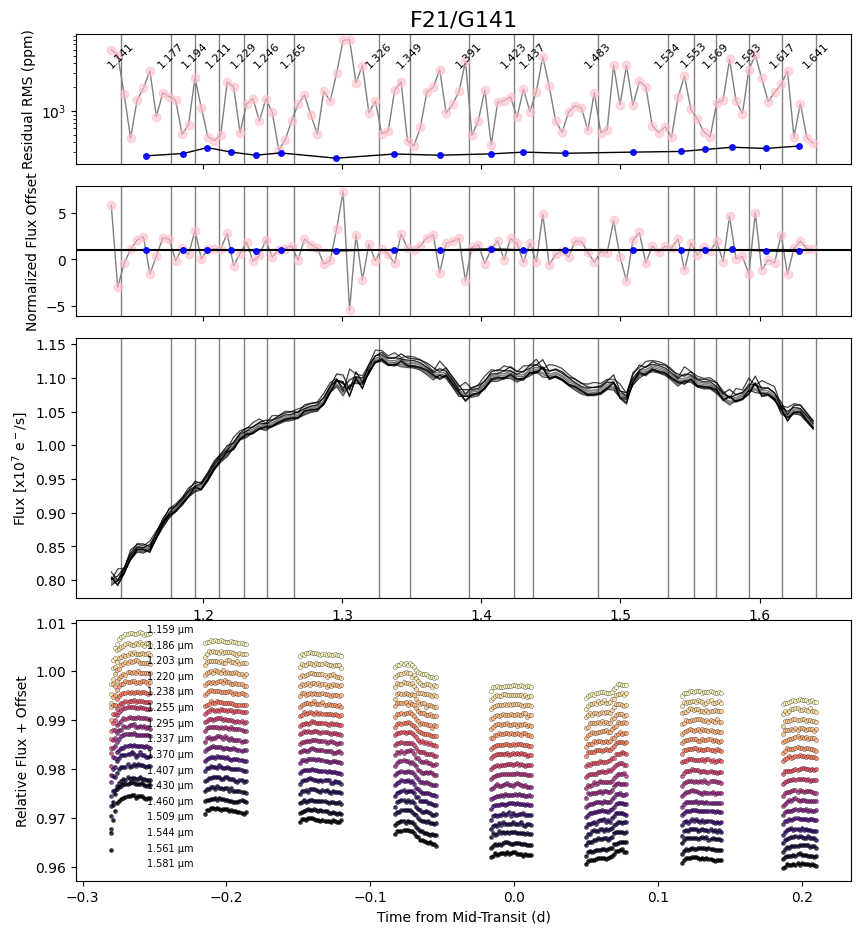

([270,
  289,
  343,
  301,
  275,
  294,
  252,
  285,
  275,
  286,
  301,
  291,
  301,
  307,
  325,
  347,
  335,
  359],
 [1.0465900503433365,
  0.9968774038518423,
  1.0549561027246261,
  0.9884725227666723,
  0.9490601521765032,
  1.033244188305982,
  0.9127555790615729,
  1.0600573520156376,
  1.0125155114787285,
  1.1336464162969624,
  1.0223067352400208,
  0.9852399826638681,
  1.051036899798078,
  1.0097408934245944,
  0.9973732718892672,
  1.064191535965192,
  0.9075108355229663,
  0.8595500310042732])

In [14]:
edges = ([1.14064	,
    1.17700,
    1.1941,
    1.2112,
    1.229,
    1.246,
    1.2649,
    1.32596,
    1.34884667,
    1.39082,
    1.42325,
    1.43715	,
    1.48348	,
    1.53444	,
    1.55297	,
    1.5685,
    1.5925	,
    1.6165,
    1.64050	]) * u.micron

for edge in edges:
    print(edge)

bin_testing(visit='F21',
            bin_edges = edges,
            print_results = True,plot=True)

## Figure 4

0.799213 micron
0.807118 micron
0.815023 micron
0.822928 micron
0.878263 micron
0.891438 micron
0.898026 micron
0.917788 micron
0.925581 micron
0.940567 micron
0.94816 micron
0.970939 micron
0.978532 micron
0.986125 micron
1.012701 micron
1.02156 micron
1.039277 micron
1.04687 micron
1.054463 micron
1.062056 micron
1.068805 micron
1.102552 micron
1.109301 micron
1.116051 micron
1.1304 micron
Wavelength Median_rel_err linear_rms r_chisq
0.79233 807 757 0.903
0.79479 764 802 1.130
0.79725 726 632 0.777
0.79971 696 667 0.944
0.80216 675 762 1.307
0.80462 659 752 1.341
0.80708 647 700 1.205
0.80954 633 703 1.270
0.81200 618 612 1.010
0.81446 607 673 1.266
0.81691 600 1064 3.222
0.81937 593 1188 4.112
0.82183 573 570 1.014
0.82429 554 492 0.813
0.82675 539 584 1.210
0.82921 531 736 1.979
0.83167 524 790 2.342
0.83412 519 704 1.898
0.83658 514 789 2.423
0.83904 509 973 3.764
0.84150 500 839 2.891
0.84396 497 942 3.699
0.84642 492 997 4.238
0.84887 487 1395 8.443
0.85133 485 1426 8.926
0.8537

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

BINNED: Wavelength Median_rel_err linear_rms r_chisq
0.80317 374 565 2.358
0.81107 348 538 2.467
0.81898 329 573 3.116
0.85060 102 713 49.757
0.88485 177 515 8.703
0.89473 241 520 4.788
0.90791 133 435 10.952
0.92168 201 565 8.097
0.93307 142 439 9.787
0.94436 195 412 4.598
0.95955 109 486 20.382
0.97474 185 411 5.068
0.98233 183 378 4.399
0.99941 97 495 26.763
1.01713 164 415 6.558
1.03042 114 370 10.747
1.04307 173 377 4.884
1.05067 173 431 6.340
1.05826 173 396 5.368
1.06543 183 397 4.842
1.08568 81 555 48.052
1.10593 181 394 4.832
1.11268 182 401 5.003
1.12323 125 354 8.189


/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_9229/3559754265.py:334: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.0)
/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_9229/3559754265.py:335: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_9229/3559754265.py:335: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


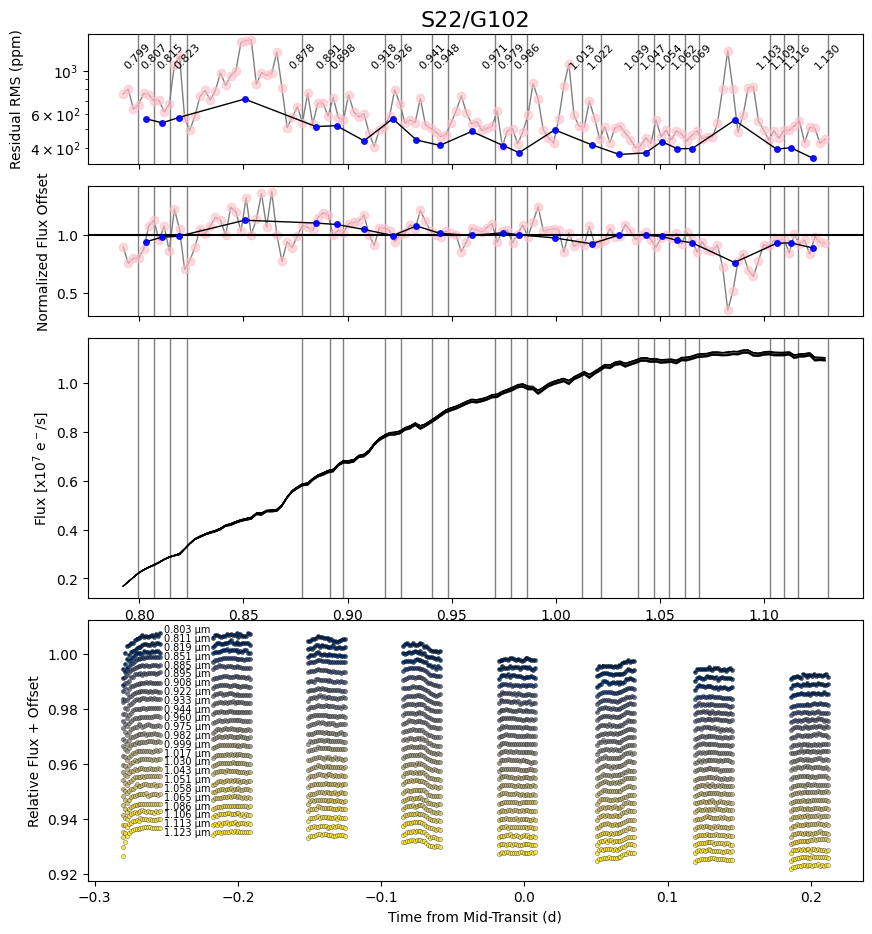

([565,
  538,
  573,
  713,
  515,
  520,
  435,
  565,
  439,
  412,
  486,
  411,
  378,
  495,
  415,
  370,
  377,
  431,
  396,
  397,
  555,
  394,
  401,
  354],
 [0.941865569098722,
  0.9830282453958533,
  0.9901088812399893,
  1.1298299354677652,
  1.1052430756638318,
  1.0928305814168464,
  1.049676691677034,
  0.99630264404116,
  1.0802508079426663,
  1.015192962290205,
  0.997831454610331,
  1.0207743654113663,
  1.0022665535483688,
  0.9756501506191761,
  0.9252213862834603,
  1.001432475152906,
  0.9980250455425939,
  0.9898228632023105,
  0.9541990881847137,
  0.9321797764098977,
  0.7618647812631025,
  0.9299529186362608,
  0.9323021264433936,
  0.8889813419161221])

In [15]:
edges = ([0.799213,
          0.807118,
          0.815023,
          0.822928,
          0.878263,
          0.891438,
          0.898026,
          0.917788, # KEEP THIS ONE
          0.925581,
          0.940567,
          0.948160,
          0.970939,
          0.978532,
          0.986125,
          1.012701,
          1.021560,
          1.039277,
          1.046870,
          1.054463,
          1.062056,
          1.068805,
          1.102552,
          1.109301,
          1.116051,
          1.1304
          ])*u.micron

for edge in edges:
    print(edge)

bin_testing(visit='S22',
            bin_edges = edges,
            print_results = True,plot=True)